In [1]:
import darshan as dardarbinks
import seaborn as sb
import pandas as pd
import darshan.backend.cffi_backend as backend

dardarbinks.enable_experimental()

from argparse import ArgumentParser
from darshan_helpers import load_dataframe
from darshan_helpers import METADATA_COLUMNS

In [2]:
import ipywidgets as widgets
from ipywidgets import interact, interactive
from IPython.display import display

special_groupings = [
    "operation_types",
    "posix_v_stdio"
]

def args(workdir, exp_type, exp_name, limit_cpu):
    return (workdir, exp_type, exp_name, limit_cpu)

arguments=interactive(args, workdir="../../data/exps", exp_type=["weak_scaling", "strong_scaling"], exp_name=["general", "phases", "sharedfs"], limit_cpu=False, limit_runs=False, continuous_update=False)
display(arguments)

interactive(children=(Text(value='../../data/exps', description='workdir'), Dropdown(description='exp_type', o…

In [8]:
# load data
# print(arguments.result)
darshan_data = load_dataframe(arguments.result[0], arguments.result[1], arguments.result[2], arguments.result[3], modules=["POSIX"])
darshan_data = darshan_data.compute()
darshan_data

Parameters:
workdir:  ../../data/exps
experiment_type:  strong_scaling
experiment_name:  general
limit_cpu:  False
modules:  ['POSIX']
../../data/exps/strong_scaling/general/1/none/false/1/wkwiecin_python_id1444075-1444075_4-7-84314-3370992330925118134_1.darshan
../../data/exps/strong_scaling/general/1/none/false/1/wkwiecin_python_id1444075-1444134_4-7-84365-10844947094824421437_1.darshan
../../data/exps/strong_scaling/general/1/none/false/1/wkwiecin_python_id1444075-1444135_4-7-84365-4576742381375372912_2.darshan
../../data/exps/strong_scaling/general/1/none/false/1/wkwiecin_python_id1444075-1444136_4-7-84365-9270629969941193407_1.darshan
../../data/exps/strong_scaling/general/128/apptainer/false/1/112512_python_id1914424-1914424_4-6-70996-6086052084729703464_1.darshan
Configuration change detected, concatenating data frames...
../../data/exps/strong_scaling/general/128/apptainer/false/1/112512_python_id1914424-1914510_4-6-71371-5194764963885973344_1.darshan
../../data/exps/strong_sca

,file_name,id,process,POSIX_OPENS,POSIX_FILENOS,POSIX_DUPS,POSIX_READS,POSIX_WRITES,POSIX_SEEKS,POSIX_STATS,...,POSIX_F_SLOWEST_RANK_TIME,POSIX_F_VARIANCE_RANK_TIME,POSIX_F_VARIANCE_RANK_BYTES,time (s),max_events,nprocs,container,option,run,basename
0,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,1512557821421132,main,2.0,2.0,0.0,3.0,0.0,1.0,0.0,...,0.0,0.0,0.0,45539.0,-1,1,none,false,1,libPersistentDataModelDict.so
0,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,7442842659344377667,shared_writer,6.0,0.0,3.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,45485.0,-1,1,none,false,1,e1hg_systematics_histos.root
0,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,7442842659344377667,evt_counter,6.0,0.0,3.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,4.0,-1,1,none,false,1,e1hg_systematics_histos.root
0,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/sw/...,4894133855480243,worker_0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,45484.0,-1,1,none,false,1,TVector3.h
1,/tmp/wkwiecin/strong_scaling/general/1/none/fa...,8274608458812029767,evt_counter,3.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,4.0,-1,1,none,false,1,AthenaMP.log
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3049,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,18406210101228840308,main,1.0,0.0,0.0,2.0,0.0,2.0,0.0,...,0.0,0.0,0.0,6007.0,-1,8,podman,false,1,CaloExtensionBuilderAlgCfg.py
3050,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,18420007739758837231,main,1.0,0.0,0.0,2.0,0.0,2.0,0.0,...,0.0,0.0,0.0,6007.0,-1,8,podman,false,1,HLTMenuConfig.py
3051,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,18424871644541287174,main,1.0,0.0,0.0,2.0,0.0,2.0,0.0,...,0.0,0.0,0.0,6007.0,-1,8,podman,false,1,TrigConfigSvcCfg.py
3052,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,18433147813827216558,main,2.0,2.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6007.0,-1,8,podman,false,1,libxAODHIEventDict.so


In [12]:
SCALING=' '.join(arguments.result[1].split('_'))
# print(darshan_data[(darshan_data["file_name"] == '/') & (darshan_data["nprocs"] != 64)])

Text(0, 0.5, 'Throughput (kEvents/h)')

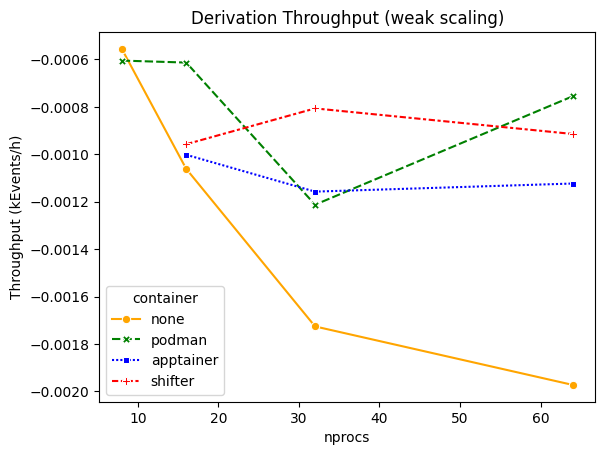

In [9]:
import seaborn as sb

color_map = {
    "apptainer": "blue",
    "none": "orange",
    "podman": "green",
    "shifter": "red"
}

throughput_df = darshan_data[["time (s)", "option"] + METADATA_COLUMNS]
throughput_df = throughput_df[(throughput_df["nprocs"] >= 8) & (throughput_df["option"] != "250")]
if SCALING == "strong scaling":
    throughput_df["max_events"] = 40000

throughput_df = throughput_df.groupby(["nprocs", "container", "option"]).agg({"time (s)": "mean", "max_events": "max"}).reset_index()
throughput_df["time (h)"] = throughput_df["time (s)"] / 3600
throughput_df["throughput"] = (throughput_df["max_events"] / 1000) / throughput_df["time (h)"]

plot = sb.lineplot(data=throughput_df[throughput_df["nprocs"] <= 64], x="nprocs", y="throughput", hue="container", markers=True, style="container", palette=color_map)
plot.set_title(f"Derivation Throughput ({SCALING})")
plot.set_ylabel("Throughput (kEvents/h)")

Text(0, 0.5, 'Throughput (kEvents/h)')

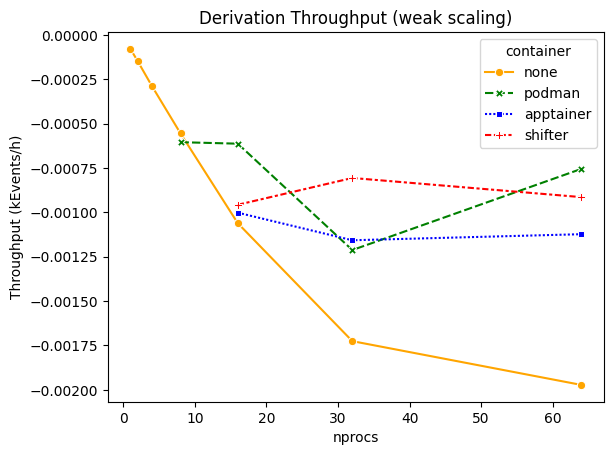

In [10]:
import seaborn as sb

color_map = {
    "apptainer": "blue",
    "none": "orange",
    "podman": "green",
    "shifter": "red"
}

throughput_df = darshan_data[["time (s)"] + METADATA_COLUMNS]
if SCALING == "strong scaling":
    throughput_df["max_events"] = 40000

throughput_df = throughput_df.groupby(["nprocs", "container"]).agg({"time (s)": "mean", "max_events": "max"}).reset_index()
throughput_df["time (h)"] = throughput_df["time (s)"] / 3600
throughput_df["throughput"] = (throughput_df["max_events"] / 1000) / throughput_df["time (h)"]

plot = sb.lineplot(data=throughput_df[throughput_df["nprocs"] <= 64], x="nprocs", y="throughput", hue="container", markers=True, style="container", palette=color_map)
plot.set_title(f"Derivation Throughput ({SCALING})")
plot.set_ylabel("Throughput (kEvents/h)")

Text(0.5, 1.0, 'Derivation Walltime (strong scaling)')

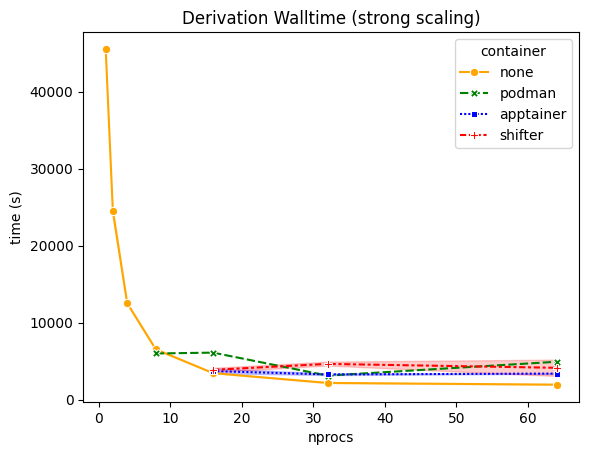

In [17]:
import seaborn as sb
module_operations = ["POSIX_READS", "POSIX_WRITES", "time (s)"] + METADATA_COLUMNS
time_df = darshan_data[module_operations]
time_df = time_df.groupby(["nprocs", "run", "container"]).agg({"time (s)": "max"}).reset_index()
plot = sb.lineplot(data=time_df[time_df["nprocs"] <= 64], x="nprocs", y="time (s)", hue="container", markers=True, style="container", palette=color_map)
plot.set_title(f"Derivation Walltime ({SCALING})")

/tmp/ipykernel_35274/588551185.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45, ha="right")


<Axes: title={'center': 'Top POSIX Files (strong scaling, nprocs=64)'}, xlabel='file_system', ylabel='POSIX_OP_TOTAL'>

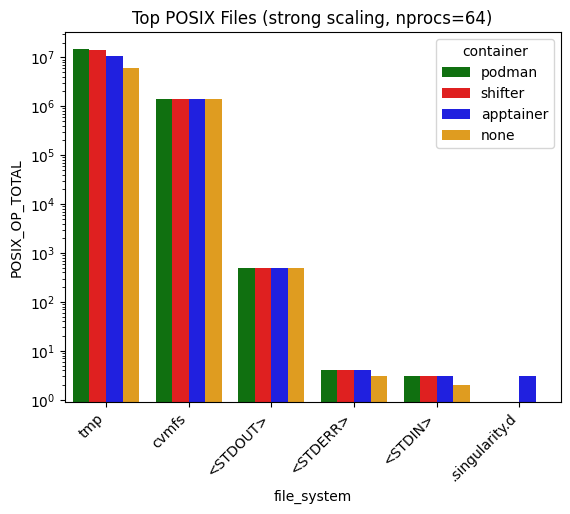

In [14]:
import seaborn as sb
import numpy as np

color_map = {
    "apptainer": "blue",
    "none": "orange",
    "podman": "green",
    "shifter": "red"
}

nprocs=64
module_operations = ["POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", "POSIX_FSYNCS", "POSIX_FDSYNCS", "POSIX_F_READ_TIME", "POSIX_F_WRITE_TIME", "POSIX_F_META_TIME"]
ext_df = darshan_data[METADATA_COLUMNS + module_operations].dropna()
ext_df["file_extension"] = ext_df["basename"].str.rsplit(".", n=1).str[-1]
# print(ext_df[ext_df["file_name"] == '/'])

fs_mask = ext_df["file_name"].str.startswith("/", na=False)
ext_df["file_system"] = np.where(fs_mask, ext_df["file_name"].str.split('/').str[1], ext_df["file_name"])
# print(ext_df[~(ext_df["file_name"].str.contains("cvmfs|tmp|<STDERR>|.singularity.d|<STDIN>|<STDOUT>|etc|usr|run", regex=True))])
# ext_df["file_system"] = ext_df["file_name"].str.split('/').str[1]

# print(ext_df["file_system"].unique())
# ext_df["file_extension"] = np.where(ext_df["file_extension"] == "1", "root", ext_df["file_extension"])
# ext_df["file_extension"] = np.where(ext_df["file_extension"] == "Derivation", "txt", ext_df["file_extension"])
ext_df = ext_df[(ext_df["run"] == "1")]

ext_df["POSIX_OP_TOTAL"] = ext_df[["POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", "POSIX_FSYNCS", "POSIX_FDSYNCS"]].sum(axis=1)
ext_df["POSIX_TIME_TOTAL"] = ext_df[["POSIX_F_READ_TIME", "POSIX_F_WRITE_TIME", "POSIX_F_META_TIME"]].sum(axis=1)
ext_df = ext_df.groupby(["nprocs", "container", "file_system"]).agg({"POSIX_OP_TOTAL": "sum", "POSIX_TIME_TOTAL": "sum"}).sort_values("POSIX_OP_TOTAL", ascending=False).reset_index()

# plot = sb.barplot(data=ext_df[ext_df["nprocs"] == nprocs].head(50), x="basename", y="POSIX_TIME_TOTAL", hue="container")
# plot.set_xticklabels(plot.get_xticklabels(), rotation=45, ha="right")
# plot.set_yscale("log")
# plot.set_title(f"Top POSIX Files ({SCALING}, nprocs={nprocs})")
# # # ext_df
# plot

plot = sb.barplot(data=ext_df[ext_df["nprocs"] == nprocs], x="file_system", y="POSIX_OP_TOTAL", hue="container", palette=color_map)
plot.set_xticklabels(plot.get_xticklabels(), rotation=45, ha="right")
plot.set_yscale("log")
plot.set_title(f"Top POSIX Files ({SCALING}, nprocs={nprocs})")
# # ext_df
plot

/tmp/ipykernel_316336/3862231950.py:10: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  seq_df = seq_df.groupby(["nprocs", "container"]).agg({"POSIX_WRITES": "sum", "POSIX_SEQ_WRITES": "sum",  "POSIX_CONSEC_WRITES": sum, "POSIX_READS": "sum", "POSIX_SEQ_READS": "sum", "POSIX_CONSEC_READS": "sum"})


<Axes: title={'center': 'Write Ratios (strong scaling, nprocs=64)'}, xlabel='nprocs,container'>

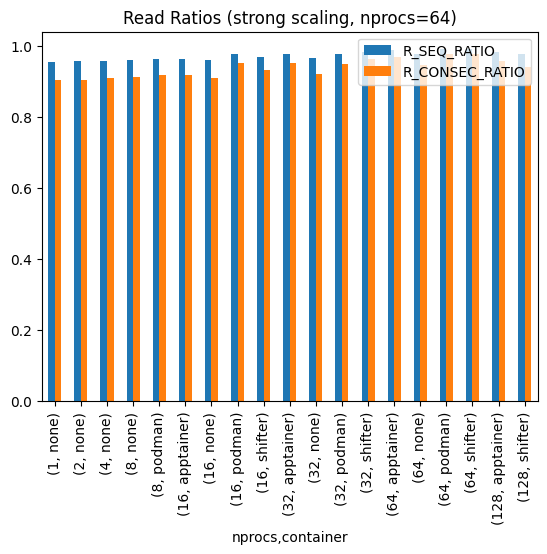

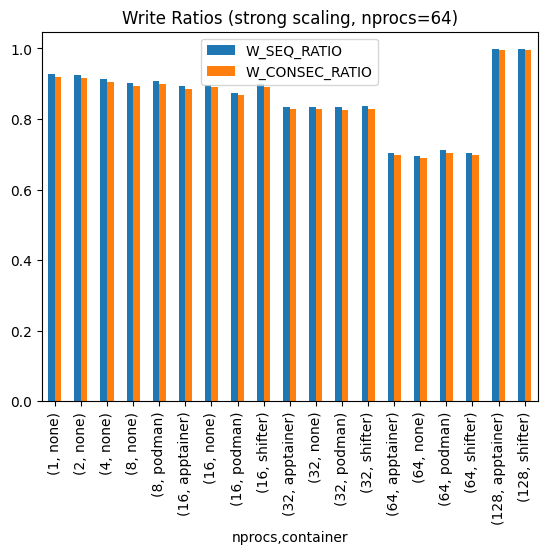

In [20]:
import seaborn as sb

write_ratio=["W_SEQ_RATIO", "W_CONSEC_RATIO"]
read_ratio=["R_SEQ_RATIO", "R_CONSEC_RATIO"]

module_operations = ["POSIX_READS", "POSIX_WRITES", "POSIX_CONSEC_READS", "POSIX_CONSEC_WRITES", "POSIX_SEQ_READS", "POSIX_SEQ_WRITES"]
seq_df = darshan_data[["file_name", "id", "process", "basename", "max_events", "nprocs", "container", "run"] + module_operations].dropna()
# seq_df["nprocs"] = pd.to_numeric(seq_df["nprocs"])
seq_df = seq_df[seq_df["run"] == "1"]
seq_df = seq_df.groupby(["nprocs", "container"]).agg({"POSIX_WRITES": "sum", "POSIX_SEQ_WRITES": "sum",  "POSIX_CONSEC_WRITES": sum, "POSIX_READS": "sum", "POSIX_SEQ_READS": "sum", "POSIX_CONSEC_READS": "sum"})
seq_df["W_SEQ_RATIO"] = seq_df["POSIX_SEQ_WRITES"] / seq_df["POSIX_WRITES"]
seq_df["W_CONSEC_RATIO"] = seq_df["POSIX_CONSEC_WRITES"] / seq_df["POSIX_WRITES"]
seq_df["R_SEQ_RATIO"] = seq_df["POSIX_SEQ_READS"] / seq_df["POSIX_READS"]
seq_df["R_CONSEC_RATIO"] = seq_df["POSIX_CONSEC_READS"] / seq_df["POSIX_READS"]

# print(seq_df)

# seq_df.plot(kind="bar", y=["POSIX_SEQ_WRITES", "POSIX_CONSEC_WRITES", "POSIX_WRITES"], stacked=True)
# sb.boxenplot(seq_df, x="nprocs", y="", hue="container")
# seq_df.plot(kind="bar", y=["R_SEQ_RATIO", "R_CONSEC_RATIO"], stacked=False)
reads = seq_df.plot(kind="bar", y=read_ratio, stacked=False)
writes = seq_df.plot(kind="bar", y=write_ratio, stacked=False)
writes.set_title(f"Write Ratios ({SCALING}, nprocs={nprocs})")
reads.set_title(f"Read Ratios ({SCALING}, nprocs={nprocs})")
writes

/tmp/ipykernel_316336/401678488.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["nprocs"] = pd.to_numeric(df["nprocs"])
/tmp/ipykernel_316336/401678488.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["POSIX_TOTAL"] = df[["POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS",
/tmp/ipykernel_316336/401678488.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

<Axes: xlabel='nprocs', ylabel='POSIX_TOTAL'>

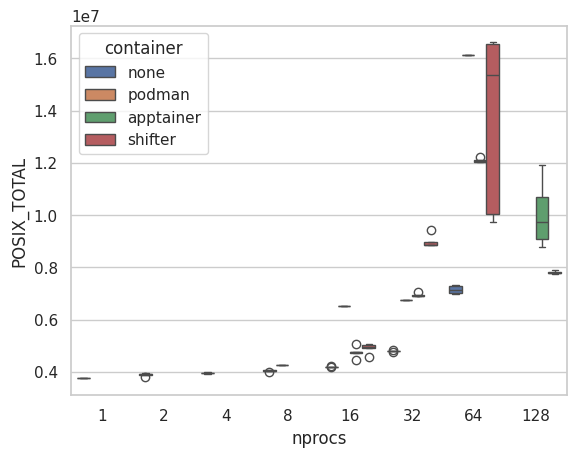

In [21]:
import seaborn as sb

module_operations = [
    "POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_MMAPS", "POSIX_FSYNCS", "POSIX_FDSYNCS", "STDIO_OPENS", "STDIO_READS",
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"
]
df = darshan_data[METADATA_COLUMNS + module_operations]

df["nprocs"] = pd.to_numeric(df["nprocs"])
df["POSIX_TOTAL"] = df[["POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_MMAPS", "POSIX_FSYNCS", "POSIX_FDSYNCS"]].sum(axis=1, numeric_only=True)
df["STDIO_TOTAL"] = df[["STDIO_OPENS", "STDIO_READS",
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"]].sum(axis=1, numeric_only=True)
df = df[METADATA_COLUMNS + ["POSIX_TOTAL", "STDIO_TOTAL"]]
df = df.sort_values(by=["nprocs"])
df = df.groupby(by=["nprocs", "run", "container"]).agg({"POSIX_TOTAL": "sum", "STDIO_TOTAL": "sum"}).reset_index()
df

sb.set_theme(style="whitegrid")
sb.boxplot(data=df, x="nprocs", y="POSIX_TOTAL", hue="container")

In [30]:
# TODO:: include stdio
# MMAPS removed due to bad value (-1), not included in data or metadata ops anyway

module_operations = [
    "POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_FSYNCS", "POSIX_FDSYNCS", "STDIO_OPENS", "STDIO_READS", 
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"
]

df = darshan_data[METADATA_COLUMNS + module_operations]
df["nprocs"] = pd.to_numeric(df["nprocs"])
df = df[df["nprocs"] <= 64]
df["POSIX_METADATA_OPS"] = df[["POSIX_OPENS", "POSIX_SEEKS", "POSIX_STATS"]].sum(axis=1, numeric_only=True)
df["POSIX_DATA_OPS"] = df[["POSIX_READS", "POSIX_WRITES", "POSIX_FSYNCS", "POSIX_FDSYNCS"]].sum(axis=1, numeric_only=True)
df["POSIX_TOTAL"] = df[["POSIX_METADATA_OPS", "POSIX_DATA_OPS"]].sum(axis=1, numeric_only=True)
df["STDIO_METADATA_OPS"] = df[["STDIO_OPENS", "STDIO_SEEKS"]].sum(axis=1, numeric_only=True)
df["STDIO_DATA_OPS"] = df[["STDIO_READS", "STDIO_WRITES"]].sum(axis=1, numeric_only=True)
df["STDIO_TOTAL"] = df[["STDIO_METADATA_OPS", "STDIO_DATA_OPS"]].sum(axis=1, numeric_only=True)
df = df.groupby(by=["nprocs", "run", "container", "file_name"]).agg({
    "process": "unique",
    "POSIX_METADATA_OPS": "sum",
    "POSIX_DATA_OPS": "sum",
    "POSIX_TOTAL": "sum",
    "STDIO_METADATA_OPS": "sum",
    "STDIO_DATA_OPS": "sum",
    "STDIO_TOTAL": "sum"
}).reset_index()
df["access_type"] = df["process"].str.len() == df["nprocs"] + 3
df["access_type"] = df["access_type"].map({True: "global", False: "local"}) # all processes accessed a file
df = df.groupby(by=["nprocs", "run", "container", "access_type"]).agg({
    "POSIX_METADATA_OPS": "sum",
    "POSIX_DATA_OPS": "sum",
    "POSIX_TOTAL": "sum",
    "STDIO_METADATA_OPS": "sum",
    "STDIO_DATA_OPS": "sum",
    "STDIO_TOTAL": "sum"
})
df = df.groupby(by=["nprocs", "container", "access_type"]).agg({
    "POSIX_METADATA_OPS": "mean",
    "POSIX_DATA_OPS": "mean",
    "POSIX_TOTAL": "mean",
    "STDIO_METADATA_OPS": "mean",
    "STDIO_DATA_OPS": "mean",
    "STDIO_TOTAL": "mean"
}).reset_index()
df["GLOBAL_POSIX_METADATA_OPS"] = df.apply(lambda row: row["POSIX_METADATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["GLOBAL_POSIX_DATA_OPS"] = df.apply(lambda row: row["POSIX_DATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["LOCAL_POSIX_METADATA_OPS"] = df.apply(lambda row: row["POSIX_METADATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df["LOCAL_POSIX_DATA_OPS"] = df.apply(lambda row: row["POSIX_DATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df["GLOBAL_STDIO_METADATA_OPS"] = df.apply(lambda row: row["STDIO_METADATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["GLOBAL_STDIO_DATA_OPS"] = df.apply(lambda row: row["STDIO_DATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["LOCAL_STDIO_METADATA_OPS"] = df.apply(lambda row: row["STDIO_METADATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df["LOCAL_STDIO_DATA_OPS"] = df.apply(lambda row: row["STDIO_DATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df.drop(columns=["POSIX_METADATA_OPS", "POSIX_DATA_OPS", "POSIX_TOTAL", "STDIO_METADATA_OPS", "STDIO_DATA_OPS", "STDIO_TOTAL", "access_type"], inplace=True)
# df["TOTAL"] = df.groupby(by=["nprocs", "container", "access_type"])["POSIX_TOTAL"].sum()
df = df.groupby(by=["nprocs", "container"]).agg({
    "GLOBAL_POSIX_METADATA_OPS": "sum",
    "GLOBAL_POSIX_DATA_OPS": "sum",
    "LOCAL_POSIX_METADATA_OPS": "sum",
    "LOCAL_POSIX_DATA_OPS": "sum",
    "GLOBAL_STDIO_METADATA_OPS": "sum",
    "GLOBAL_STDIO_DATA_OPS": "sum",
    "LOCAL_STDIO_METADATA_OPS": "sum",
    "LOCAL_STDIO_DATA_OPS": "sum"
})
df["TOTAL_POSIX_OPS"] = df["GLOBAL_POSIX_METADATA_OPS"] + df["GLOBAL_POSIX_DATA_OPS"] + df["LOCAL_POSIX_METADATA_OPS"] + df["LOCAL_POSIX_DATA_OPS"]
df["TOTAL_STDIO_OPS"] = df["GLOBAL_STDIO_METADATA_OPS"] + df["GLOBAL_STDIO_DATA_OPS"] + df["LOCAL_STDIO_METADATA_OPS"] + df["LOCAL_STDIO_DATA_OPS"]

/tmp/ipykernel_316336/1728745454.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["nprocs"] = pd.to_numeric(df["nprocs"])


<Axes: xlabel='nprocs,container'>

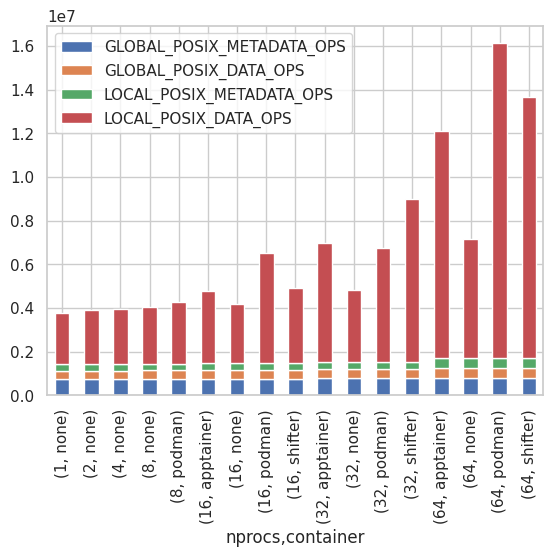

In [31]:
import seaborn as sb
df.plot(kind="bar", y=["GLOBAL_POSIX_METADATA_OPS", "GLOBAL_POSIX_DATA_OPS", "LOCAL_POSIX_METADATA_OPS", "LOCAL_POSIX_DATA_OPS"], stacked=True)

<Axes: xlabel='nprocs,container'>

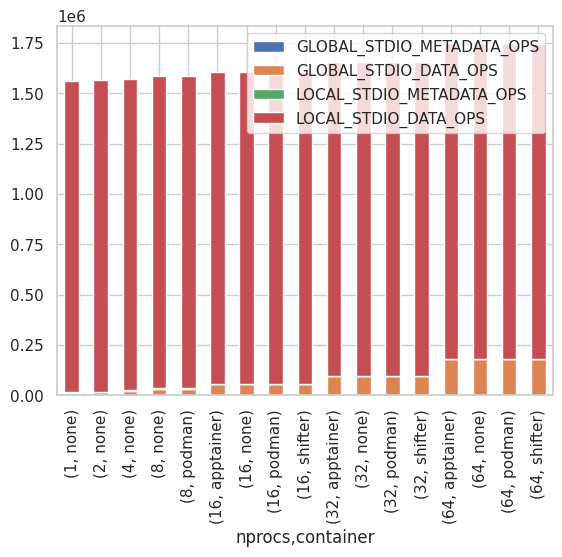

In [32]:
import seaborn as sb
df.plot(kind="bar", y=["GLOBAL_STDIO_METADATA_OPS", "GLOBAL_STDIO_DATA_OPS", "LOCAL_STDIO_METADATA_OPS", "LOCAL_STDIO_DATA_OPS"], stacked=True)

      nprocs  container      process run  POSIX_READS  POSIX_WRITES
1589      64  apptainer  evt_counter   1       2669.0          35.0
1726      64       none  evt_counter   4       1852.0          35.0
1725      64       none  evt_counter   3       2182.0          35.0
1724      64       none  evt_counter   2       2184.0          35.0
1723      64       none  evt_counter   1       2180.0          35.0
...      ...        ...          ...  ..          ...           ...
1978      64       none    worker_63   4     140137.0          25.0
1716      64  apptainer    worker_63   2     428715.0          29.0
1975      64       none    worker_63   1     145483.0          27.0
2054      64     podman    worker_63   1     218510.0          26.0
1977      64       none    worker_63   3     134842.0          25.0

[536 rows x 6 columns]


/tmp/ipykernel_19447/712186858.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


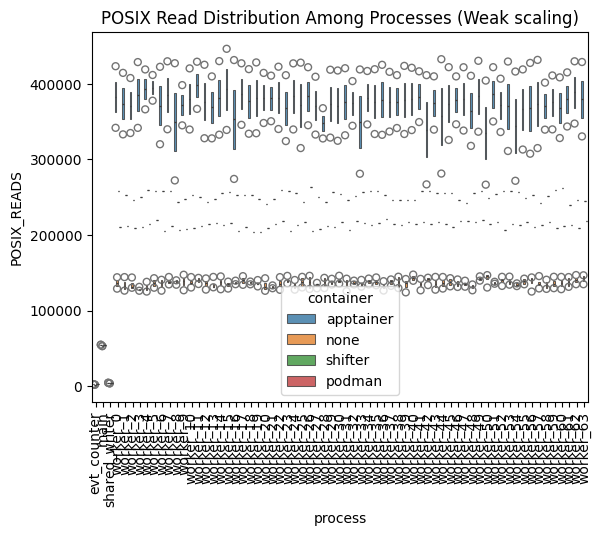

      nprocs  container        process run  POSIX_READS  POSIX_WRITES
1593      64  apptainer  shared_writer   1       4564.0      477999.0
1594      64  apptainer  shared_writer   2       4563.0      471828.0
2060      64    shifter  shared_writer   1       4562.0      477963.0
1731      64       none  shared_writer   1       3748.0      463397.0
1732      64       none  shared_writer   2       3746.0      487230.0
1733      64       none  shared_writer   3       3746.0      457960.0
1734      64       none  shared_writer   4       3744.0      475186.0
1993      64     podman  shared_writer   1       4560.0      472627.0


/tmp/ipykernel_19447/712186858.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot2.set_xticklabels(plot2.get_xticklabels(), rotation=90)


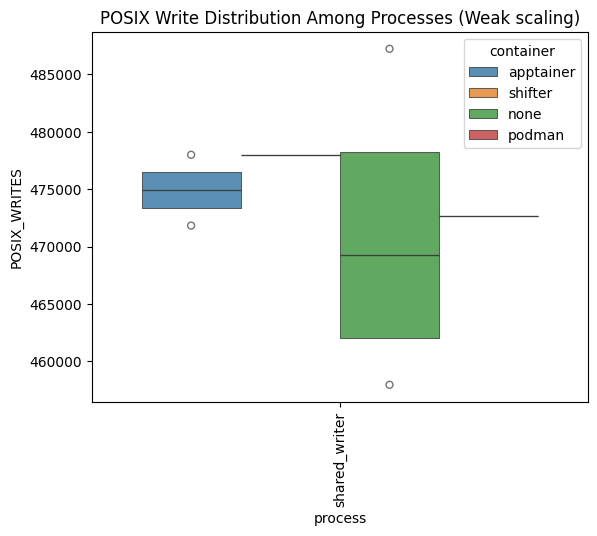

In [4]:
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
import re
from natsort import natsort_keygen
# from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))

GROUPINGS = {
    "evt_counter": "evt_counter",
    "main": "main",
    "shared_writer": "shared_writer",
}

def natural_sort_key(s):
    """Convert string into a list of str and int chunks for natural sorting."""
    return [int(c) if c.isdigit() else c.lower() for c in re.split(r'(\d+)', s)]

# find the distribution of reads and writes among processes
distribution_df = darshan_data[METADATA_COLUMNS + ["POSIX_READS", "POSIX_WRITES"]]
distribution_df = distribution_df.drop(columns=["id", "max_events"])
# distribution_df["group"] = distribution_df["process"].map(lambda x: GROUPINGS.get(x, "worker"))

distribution_df = distribution_df.groupby(by=["nprocs", "container", "process", "run"]).sum(numeric_only=True).reset_index()
# distribution_df = distribution_df.groupby(by=["nprocs", "container", "process"]).agg({"POSIX_READS": "mean", "POSIX_WRITES": "mean"}).reset_index()
# distribution_df

distribution_df["process"] = distribution_df["process"].astype(str)
distribution_df = distribution_df[distribution_df["nprocs"] == 64]
# distribution_df = distribution_df[distribution_df["container"] == "podman"]

distribution_df.sort_values(by="process", inplace=True, key=natsort_keygen())

print(distribution_df)

# sn.set_theme(style='whitegrid')
# palette = sn.color_palette('tab10')
# color1, color2 = palette[0], palette[1]
# fig, axs = plt.subplots(1,2)

plot = sn.boxenplot(data=distribution_df, x="process", y="POSIX_READS", hue="container", alpha=0.8)
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
plt.title(f'POSIX Read Distribution Among Processes ({" ".join(arguments.result[1].split("_")).capitalize()})')
plt.show()

print(distribution_df[distribution_df["process"] == "shared_writer"])

plot2 = sn.boxenplot(data=distribution_df[distribution_df["process"] == "shared_writer"], x="process", y="POSIX_WRITES", hue="container", alpha=0.8)
plot2.set_xticklabels(plot2.get_xticklabels(), rotation=90)
plt.title(f'POSIX Write Distribution Among Processes ({" ".join(arguments.result[1].split("_")).capitalize()})')
plt.show()
# fig, ax1 = plt.subplots(figsize=(9, 5))
# ax2 = ax1.twinx()

# # Compute bar positions manually so the two sets don't overlap
# n = len(distribution_df)
# x = np.arange(n)
# width = 0.35

# # --- Left Y-axis: first bar plot ---
# ax1.bar(x - width / 2, distribution_df['POSIX_READS'], width=width, color=color1, alpha=0.8, label='POSIX_READS')
# ax1.set_ylabel('POSIX_READS', color=color1)
# ax1.tick_params(axis='y', labelcolor=color1)
# ax1.tick_params(axis='x', rotation=90)
# ax1.set_xticks(x)
# ax1.set_xticklabels(distribution_df['process'])
# ax1.set_xlabel('Process')

# # --- Right Y-axis: second bar plot ---
# ax2.bar(x + width / 2, distribution_df['POSIX_WRITES'], width=width, color=color2, alpha=0.8, label='POSIX_WRITES')
# ax2.set_ylabel('POSIX_WRITES', color=color2)
# ax2.tick_params(axis='y', labelcolor=color2)

# # --- Combined legend ---
# handles = [
#     plt.Rectangle((0, 0), 1, 1, color=color1, alpha=0.8),
#     plt.Rectangle((0, 0), 1, 1, color=color2, alpha=0.8)
# ]
# ax1.legend(handles, ['POSIX_READS', 'POSIX_WRITES'], loc='upper left')

# fig.tight_layout()
# plt.savefig('dual_axis_two_bars.png', dpi=150)
# plt.show()
# fig
# plt.show(plot)
# plt.show(plot2)

In [9]:
# darshan_data[(darshan_data["container"] == "shifter")]["nprocs"].unique()
darshan_data["limit_cpu"].unique()

array([ True])

In [ ]:
# check sequential IO